In [4]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta
from datetime import date

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter

import eurostat #python wrapper for taking data. 
import time

import os

Share_point = r'C:\Users\ugne.keliauskaite\Bruegel\Research - 2021-11 European natural gas imports\Code\LNG terminals' #Ugne
os.chdir(Share_point)

Points_APIs = pd.read_excel(r'Dataproviders 27.05.2025.xlsx',sheet_name='LNG terminals') # good practice would be to update the Dataproviders file every few months
headers = {"x-key":"17d04ee4a722c5013cd92c83f08122a2"}


### Restart here

In [5]:
d1 = '2025-07-01'
d2 = '2025-12-31' # To change in the new year

In [6]:
import json  # Ensure you import the json module
import requests  # Ensure you import the requests module

dates = []
sendOut = []
stored = []
max_storage = []
max_sendout = []
country = []
Name = []

for item in range(len(Points_APIs)):
    url = Points_APIs.iloc[item, 3] + '&from={}&to={}&size=300'.format(d1, d2)
    try:
        r = requests.get(url, headers=headers)
        if r.status_code != 200:
            print(r.status_code)
            print(url)
            continue

        raw_data = r.json()
        inner_data = raw_data['data']
        for x in inner_data:
            # here we work with the APIs
            date = x['gasDayStart']

            # Process 'inventory' to extract the last value
            inventory_data = x['inventory']
            if isinstance(inventory_data, str):  # Convert string to dict if necessary
                try:
                    inventory_data = json.loads(inventory_data)
                except json.JSONDecodeError as json_err:
                    print(f"Error decoding inventory data: {json_err}, data: {inventory_data}")
                    continue
            if isinstance(inventory_data, dict):  # Extract the last value from the dict
                inventory_values = list(inventory_data.values())
                if inventory_values and inventory_values[-1] != '-':
                    try:
                        inventory = float(inventory_values[-1])
                    except ValueError as ve:
                        print(f"Error converting inventory to float: {ve}, data: {inventory_values[-1]}")
                        continue
                else:
                    inventory = None  # or some default value

            sendOuts = x['sendOut']

            # Process 'Max_Storage' to extract the last value
            Max_Storage_data = x['dtmi']
            if isinstance(Max_Storage_data, str):  # Convert string to dict if necessary
                try:
                    Max_Storage_data = json.loads(Max_Storage_data)
                except json.JSONDecodeError as json_err:
                    print(f"Error decoding Max_Storage data: {json_err}, data: {Max_Storage_data}")
                    continue
            if isinstance(Max_Storage_data, dict):  # Extract the last value from the dict
                Max_Storage_values = list(Max_Storage_data.values())
                if Max_Storage_values and Max_Storage_values[-1] != '-':
                    try:
                        Max_Storage = float(Max_Storage_values[-1])
                    except ValueError as ve:
                        print(f"Error converting Max_Storage to float: {ve}, data: {Max_Storage_values[-1]}")
                        continue
                else:
                    Max_Storage = None  # or some default value

            Max_Sendout = x['dtrs']

            # here we work with the excel file
            countries = Points_APIs.iloc[item, 0]
            Names = Points_APIs.iloc[item, 5]

            dates.append(date)
            sendOut.append(sendOuts)
            stored.append(inventory)  # Append the last value of 'inventory'
            max_storage.append(Max_Storage)  # Append the last value of 'Max_Storage'
            max_sendout.append(Max_Sendout)
            country.append(countries)
            Name.append(Names)
    except Exception as e:
        print(f"Error processing URL {url}: {e}")


In [7]:
df = pd.DataFrame()
df['dates'] = dates
df['sendOut'] = sendOut          ## in GWh/d
df['stored'] = stored            ## in 10^3 m^3 LNG
df['Max Storage'] = max_storage  ## in 10^3 m^3 LNG
df['Max Sendout'] = max_sendout  ## in GWh/d
df['country'] = country
df['name'] = Name
df.replace('-', np.NaN,inplace=True)

# trasfom all the numerical observation into numbers
df['sendOut'] = pd.to_numeric(df['sendOut'])
df['stored'] = pd.to_numeric(df['stored'])
df['Max Storage'] = pd.to_numeric(df['Max Storage']) 
df['Max Sendout'] = pd.to_numeric(df['Max Sendout'])
df.shape

(6929, 7)

In [8]:
from datetime import date
df.to_csv('raw_data/2025_2.csv')

###  merge with historic data

In [9]:
# Change current directory
import os
os.chdir(Share_point + '\\raw_data')

df_1 = pd.read_csv('2015.csv',index_col=0)
df_2 = pd.read_csv('2016.csv',index_col=0)
df_3 = pd.read_csv('2017.csv',index_col=0)
df_4 = pd.read_csv('2018.csv',index_col=0)
df_5a = pd.read_csv('2019_1.csv',index_col=0)
df_5b = pd.read_csv('2019_2.csv',index_col=0)
df_6a = pd.read_csv('2020_1.csv',index_col=0)
df_6b = pd.read_csv('2020_2.csv',index_col=0)
df_7a = pd.read_csv('2021_1.csv',index_col=0)
df_7b = pd.read_csv('2021_2.csv',index_col=0)
df_8a = pd.read_csv('2022_1.csv',index_col=0)
df_8b = pd.read_csv('2022_2.csv',index_col=0)
df_9a = pd.read_csv('2023_1.csv',index_col=0)
df_9b = pd.read_csv('2023_2.csv',index_col=0)
df_10a = pd.read_csv('2024_1.csv',index_col=0)
df_10b = pd.read_csv('2024_2.csv',index_col=0)
df_11a = pd.read_csv('2025_1.csv',index_col=0)
df_11b = pd.read_csv('2025_2.csv',index_col=0)
df_11av2 = pd.read_csv('2025_1_2025_02_25.csv',index_col=0)
df_11av3 = pd.read_csv('2025_1_2025_03_27.csv',index_col=0)

df = pd.concat([df_1,df_2,df_3,df_4,df_5a,df_5b,df_6a,df_6b,df_7a,df_7b,df_8a,df_8b,df_9a,df_9b,df_10a, df_10b, df_11a])
df_old02 = pd.concat([df_1,df_2,df_3,df_4,df_5a,df_5b,df_6a,df_6b,df_7a,df_7b,df_8a,df_8b,df_9a,df_9b,df_10a, df_10b, df_11av2])
df_old03 = pd.concat([df_1,df_2,df_3,df_4,df_5a,df_5b,df_6a,df_6b,df_7a,df_7b,df_8a,df_8b,df_9a,df_9b,df_10a, df_10b, df_11av3])

# df = df.drop_duplicates()
# df_old02 = df_old02.drop_duplicates()
# df_old03 = df_old03.drop_duplicates()


In [10]:
# df_old02 = pd.concat([df_1,df_2,df_3,df_4,df_5a,df_5b,df_6a,df_6b,df_7a,df_7b,df_8a,df_8b,df_9a,df_9b,df_10a, df_10b, df_11av2])
# df_old03 = pd.concat([df_1,df_2,df_3,df_4,df_5a,df_5b,df_6a,df_6b,df_7a,df_7b,df_8a,df_8b,df_9a,df_9b,df_10a, df_10b, df_11av3])


In [11]:
# df_new = df

# df_new['dates'] = pd.to_datetime(df_new['dates'])
# df_new['week'] = df_new['dates'].dt.isocalendar().week
# df_new['year'] = df_new['dates'].dt.isocalendar().year
# df_new_2025 = df_new[(df_new['dates'] >= '2024-12-30') & (df_new['dates'] <= '2025-12-28')]
# df_new_2025[['dates', 'name', 'sendOut', 'week']].sort_values(['name', 'week', 'dates']).head(20)
# df_new_2025

In [12]:
df_new = df
df_old =df_old03

# NEW
df_new['dates'] = pd.to_datetime(df_new['dates'])
df_new['week'] = df_new['dates'].dt.isocalendar().week
df_new['year'] = df_new['dates'].dt.isocalendar().year

# OLD
df_old['dates'] = pd.to_datetime(df_old['dates'], dayfirst=True, errors='coerce')  # safer parsing
df_old['week'] = df_old['dates'].dt.isocalendar().week
df_old['year'] = df_old['dates'].dt.isocalendar().year

# --- FILTER both to 2025 weeks ---
df_new_filt = df_new[(df_new['dates'] >= '2024-12-30') & (df_new['dates'] <= '2025-12-28')]
df_old_filt = df_old[(df_old['dates'] >= '2024-12-30') & (df_old['dates'] <= '2025-12-28')]

# --- GROUP BY name + week and SUM sendOut ---
new_weekly = df_new_filt.groupby(['name', 'week'])['sendOut'].sum().reset_index()
old_weekly = df_old_filt.groupby(['name', 'week'])['sendOut'].sum().reset_index()

# --- MERGE & COMPARE ---
weekly_diff = pd.merge(
    new_weekly, old_weekly,
    on=['name', 'week'],
    how='outer',
    suffixes=('_new', '_old')
)

# Fill missing sendOut values with 0 (i.e. if a terminal-week combo was missing in one version)
weekly_diff['sendOut_new'] = weekly_diff['sendOut_new'].fillna(0)
weekly_diff['sendOut_old'] = weekly_diff['sendOut_old'].fillna(0)

# Calculate difference
weekly_diff['diff'] = weekly_diff['sendOut_new'] - weekly_diff['sendOut_old']
weekly_diff = weekly_diff[weekly_diff['week'] <=12]
weekly_diff


,name,week,sendOut_new,sendOut_old,diff
0,Alexandroupolis LNG Terminal (FSRU Alexandroup...,1,200.4,200.4,0.0
1,Alexandroupolis LNG Terminal (FSRU Alexandroup...,2,319.6,319.6,0.0
2,Alexandroupolis LNG Terminal (FSRU Alexandroup...,3,293.5,293.5,0.0
3,Alexandroupolis LNG Terminal (FSRU Alexandroup...,4,229.8,198.6,31.2
4,Alexandroupolis LNG Terminal (FSRU Alexandroup...,5,31.3,31.3,0.0
...,...,...,...,...,...
1087,Świnoujście LNG Terminal,8,1718.4,1718.4,0.0
1088,Świnoujście LNG Terminal,9,1420.5,1420.5,0.0
1089,Świnoujście LNG Terminal,10,1759.3,1759.3,0.0
1090,Świnoujście LNG Terminal,11,1774.0,1774.0,0.0


In [14]:
weekly_totals = weekly_diff.groupby('week')[['sendOut_new', 'sendOut_old', 'diff']].sum().reset_index()
weekly_totals

,week,sendOut_new,sendOut_old,diff
0,1,26391.5,26391.5,2.220446e-16
1,2,27480.7,27480.7,0.000000e+00
2,3,31260.2,31260.2,0.000000e+00
3,4,30076.8,30045.6,3.120000e+01
4,5,29154.0,29152.1,1.900000e+00
5,6,34128.6,34127.1,1.500000e+00
6,7,33115.6,33102.2,1.340000e+01
7,8,31029.9,31073.3,-4.340000e+01
8,9,32603.4,32648.9,-4.550000e+01
9,10,32132.9,32109.3,2.360000e+01


In [15]:
# df_old = df_old02

# df_old['dates'] = pd.to_datetime(df_old['dates'])
# df_old['week'] = df_old['dates'].dt.isocalendar().week
# df_old['year'] = df_old['dates'].dt.isocalendar().year
# df_old_2025 = df_old[(df_old['dates'] >= '2024-12-30') & (df_old['dates'] <= '2025-12-28')]
# df_old_2025[['dates', 'name', 'sendOut', 'week']].sort_values(['name', 'week', 'dates']).head(20)
# df_old_2025

In [16]:
df_new_2025.groupby('week').size().sort_index()

NameError: name 'df_new_2025' is not defined

In [ ]:
df_old_2025.groupby('week').size().sort_index()

NameError: name 'df_old_2025' is not defined

In [17]:
from datetime import date
today = date.today()
# this is used to have Sunday's observation as last ones when running on Wednesday (most recent data often partially missing)
last_obs = today - timedelta(days=2)  # you want it equal to 2 on Tuesday and 3 on Wednesday

df = df.set_index(pd.DatetimeIndex(df['dates']))
del df['dates']
df = df.sort_values(by='dates')

In [18]:
# check countries
df.country.unique()

array(['ES', 'IT', 'FR', 'NL', 'PT', 'GR', 'BE', 'GB', 'LT', 'PL', 'ES*',
       'GB*', 'HR', 'DE', 'FI'], dtype=object)

In [96]:
# Change current directory
import os
os.chdir(Share_point)
# group by date and country (for countries with multiple terminals)
df_C = df.groupby(['dates','country']).sum().reset_index()
df_C = df_C.set_index(pd.DatetimeIndex(df_C['dates']))


C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_47796\3455554222.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_C = df.groupby(['dates','country']).sum().reset_index()


## regassification % - Weekly data

In [97]:
from datetime import date
today = date.today()
last_obs = today - timedelta(days=2) # can be also -3
print(last_obs)
# enddate = datetime.strptime('2022-07-17', "%d-%m-%Y") this useful only if done manually
enddate = last_obs
startdate = enddate - timedelta(days=30)  # to be removed?

df_w = df_C.groupby([pd.Grouper(freq='W'),'country']).sum().reset_index()
df_w=df_w.set_index(pd.DatetimeIndex(df_w['dates']))

# check countries
df_w.country.unique()

df_w = df_w[~df_w.country.isin(['ES*','GB','GB*'])] # Get rid of UK and ES TVB aggregate --> for which there is no data pre-2020
del df_w['dates']

2025-11-23


C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_47796\1320015632.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_w = df_C.groupby([pd.Grouper(freq='W'),'country']).sum().reset_index()


In [98]:
## Can change from new year
data = pd.DataFrame()
data['week'] = list(range(0,54,1))

# plot = df_w.groupby([pd.Grouper(freq='W'),'country']).sum()[:] ## use a converter if you want to transform the data
df_w['week'] = df_w.index.isocalendar().week

hist = df_w['2019-01-05':'2022-01-02'].groupby(['country','week']).mean().reset_index()
values2021 = df_w.loc['2020-12-28':'2022-01-02'].groupby(['country','week']).max().reset_index()
values2022 = df_w.loc['2022-01-03':'2023-01-01'].groupby(['country','week']).max().reset_index()
values2023 = df_w.loc['2023-01-01':'2023-12-31'].groupby(['country','week']).max().reset_index()
values2024 = df_w.loc['2024-01-01':'2024-12-29'].groupby(['country','week']).max().reset_index()
values2025 = df_w.loc['2024-12-30':'2025-12-28'].groupby(['country','week']).max().reset_index()

hist['regas %'] = (hist['sendOut']/hist['Max Sendout'])*100
values2021['regas %'] = (values2021['sendOut']/values2021['Max Sendout'])*100
values2022['regas %'] = (values2022['sendOut']/values2022['Max Sendout'])*100
values2023['regas %'] = (values2023['sendOut']/values2023['Max Sendout'])*100
values2024['regas %'] = (values2024['sendOut']/values2024['Max Sendout'])*100
values2025['regas %'] = (values2025['sendOut']/values2025['Max Sendout'])*100

In [99]:
values2025

,country,week,sendOut,stored,Max Storage,Max Sendout,year,regas %
0,BE,1,2104.1,11632.18,26328.70,4958.3,14175,42.435916
1,BE,2,2035.6,13218.35,26362.87,5068.7,14175,40.160199
2,BE,3,566.6,7302.31,26384.62,5068.7,14175,11.178409
3,BE,4,854.0,5542.13,26203.56,5068.7,14175,16.848502
4,BE,5,1837.1,13354.41,26455.52,5068.7,14175,36.244007
...,...,...,...,...,...,...,...,...
319,PT,23,840.6,13260.66,18662.37,1400.0,14175,60.042857
320,PT,24,793.3,13136.79,18662.24,1400.0,14175,56.664286
321,PT,25,761.1,8334.03,18662.29,1400.0,14175,54.364286
322,PT,26,783.0,15850.06,18662.32,1400.0,14175,55.928571


In [1]:
import pandas as pd
from pandas.tseries.offsets import DateOffset

# Step 1: Copy and prepare week_start
df = values2025.copy()
df['week'] = df['week'].astype(int)
df['week_start'] = pd.to_datetime('2025-W' + df['week'].astype(str).str.zfill(2) + '-1', format='%G-W%V-%u')

# Step 2: Identify the most recent week in the data
most_recent_week = df['week_start'].max()

# Step 3: Calculate 2-month window ending before the most recent week
two_months_before = most_recent_week - DateOffset(months=2)

# Step 4: Filter weeks within that 2-month window, excluding the latest week
filtered_df = df[(df['week_start'] >= two_months_before) & (df['week_start'] < most_recent_week)]

# Step 5: Group and average regas %
average_regas_by_country = (
    filtered_df.groupby('country')['regas %']
    .mean()
    .reset_index()
    .rename(columns={'regas %': 'avg_regas_pct_last_2_months'})
    .sort_values(by='avg_regas_pct_last_2_months', ascending=False)
)

# Step 6: Display results
print(average_regas_by_country)


NameError: name 'values2025' is not defined

In [125]:
df

,country,week,sendOut,stored,Max Storage,Max Sendout,year,regas %,week_start
0,BE,1,2104.1,11632.18,26328.70,4958.3,14175,42.435916,2024-12-30
1,BE,2,2035.6,13218.35,26362.87,5068.7,14175,40.160199,2025-01-06
2,BE,3,566.6,7302.31,26384.62,5068.7,14175,11.178409,2025-01-13
3,BE,4,854.0,5542.13,26203.56,5068.7,14175,16.848502,2025-01-20
4,BE,5,1837.1,13354.41,26455.52,5068.7,14175,36.244007,2025-01-27
...,...,...,...,...,...,...,...,...,...
319,PT,23,840.6,13260.66,18662.37,1400.0,14175,60.042857,2025-06-02
320,PT,24,793.3,13136.79,18662.24,1400.0,14175,56.664286,2025-06-09
321,PT,25,761.1,8334.03,18662.29,1400.0,14175,54.364286,2025-06-16
322,PT,26,783.0,15850.06,18662.32,1400.0,14175,55.928571,2025-06-23


In [126]:
import os
#os.chdir(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Data\LNG')
os.chdir(r'C:\Users\ugne.keliauskaite\Bruegel\Research - 2021-11 European natural gas imports\Data\LNG')
# saves the data in excel
Excelwriter = pd.ExcelWriter(r"GIE ALSI LNG terminals\LNG_GIE_weekly_data {}.xlsx".format(today),engine="xlsxwriter")
hist.to_excel(Excelwriter, sheet_name="2019-2021", index=False)
values2021.to_excel(Excelwriter, sheet_name="2021", index=False)
values2022.to_excel(Excelwriter, sheet_name="2022", index=False)
values2023.to_excel(Excelwriter, sheet_name="2023", index=False)
values2024.to_excel(Excelwriter, sheet_name="2024", index=False)
values2025.to_excel(Excelwriter, sheet_name="2025", index=False)
average_regas_by_country.to_excel(Excelwriter, sheet_name="two_month_average", index=False)
Excelwriter.close()
Excelwriter.save()

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_47796\2670777218.py:14: FutureWarning: save is not part of the public API, usage can give unexpected results and will be removed in a future version
  Excelwriter.save()
c:\Users\ugne.keliauskaite\AppData\Local\anaconda3\Lib\site-packages\xlsxwriter\workbook.py:368: UserWarning: Calling close() on already closed file.
  warn("Calling close() on already closed file.")


## LNG send outs - weekly (for the ENTSOG imports file)

In [104]:
cplot = df.loc[~df['country'].isin(['GB','GB*'])].reset_index() # getting rid of UK data 
cplot['week_start'] = pd.to_datetime(cplot['week_start'])  # Convert the date column to datetime
cplot.country.unique()
cplot

,index,country,week,sendOut,stored,Max Storage,Max Sendout,year,regas %,week_start
0,0,BE,1,2104.1,11632.18,26328.70,4958.3,14175,42.435916,2024-12-30
1,1,BE,2,2035.6,13218.35,26362.87,5068.7,14175,40.160199,2025-01-06
2,2,BE,3,566.6,7302.31,26384.62,5068.7,14175,11.178409,2025-01-13
3,3,BE,4,854.0,5542.13,26203.56,5068.7,14175,16.848502,2025-01-20
4,4,BE,5,1837.1,13354.41,26455.52,5068.7,14175,36.244007,2025-01-27
...,...,...,...,...,...,...,...,...,...,...
319,319,PT,23,840.6,13260.66,18662.37,1400.0,14175,60.042857,2025-06-02
320,320,PT,24,793.3,13136.79,18662.24,1400.0,14175,56.664286,2025-06-09
321,321,PT,25,761.1,8334.03,18662.29,1400.0,14175,54.364286,2025-06-16
322,322,PT,26,783.0,15850.06,18662.32,1400.0,14175,55.928571,2025-06-23


In [105]:
# # to keep only TVB (Virtual balancing LNG tank) after July 2020
# # TVB --> virtual balanging LNG for all country's terminals (country ES*)
# # Filter the DataFrame to keep only specific names after July 2020
# es_lng_points = ['Bilbao LNG Terminal', 'Cartagena LNG Terminal', 'Barcelona LNG Terminal', 'Mugardos LNG Terminal','Huelva LNG Terminal','Sagunto LNG Terminal']
# date_threshold = pd.to_datetime('2020-07-09')
# ccplot = cplot[~((cplot['name'].isin(es_lng_points)) & (cplot['dates'] >= date_threshold))]
# # just a check that the above cell worked (can get rid of it). We want single terminals before 2020-07-09 and the TVB aggregate afterwards
# ccplot[ccplot['country']=='ES']

In [106]:
es = ccplot[(ccplot['country']=='ES*')].index
# now change the country to 'ES' also for balancing point TVB
for i in es:
    ccplot.loc[i,'country']='ES'

# reset index
ccplot = ccplot.reset_index()
ccplot=ccplot.set_index(pd.DatetimeIndex(ccplot['dates']))
del ccplot['dates']

# here we upload the LNG file on Sharepoint
ccplot.to_csv(r'C:\Users\ugne.keliauskaite\Bruegel\Research - 2021-11 European natural gas imports\Code\LNG terminals\raw_data\agsi.csv') # Ugne 

NameError: name 'ccplot' is not defined

In [107]:
ccplot
ccplot.info()

NameError: name 'ccplot' is not defined

In [108]:
# ------------------------------------------------------------------------------------------- can disregard from here (mostly checks) --------------------------------------------------------------------------------------------------------

In [109]:
cplot=cplot.set_index(pd.DatetimeIndex(cplot['dates']))

KeyError: 'dates'

In [110]:
cplot_week = cplot.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
cplot_week['week'] = cplot_week.index.isocalendar().week

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'

In [111]:
cplot_week['M3m']=round(cplot_week['sendOut']/10.3,1)

NameError: name 'cplot_week' is not defined

In [112]:
cplot_week

NameError: name 'cplot_week' is not defined

In [113]:
cplot_week['M3m']['2023':].plot()

NameError: name 'cplot_week' is not defined

## CHECKS: LNG send-outs  - Monthly

In [114]:
cplot = df.loc[~df['country'].str.startswith('GB')]

In [115]:
cplot_month =  cplot.groupby([pd.Grouper(freq='M'),'country']).sum(numeric_only=True).reset_index() #/converter

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Int64Index'

In [116]:
cplot_month['M3m'] = round(cplot_month['sendOut']/10.3,1)
print(cplot_month.tail())

NameError: name 'cplot_month' is not defined

In [117]:
cmonth = pd.pivot_table(cplot_month,values='M3m',index='dates',columns='country')

NameError: name 'cplot_month' is not defined

In [118]:
cmonth= cmonth['2021-01':'2023-09']

NameError: name 'cmonth' is not defined

In [119]:
cmonth.columns

NameError: name 'cmonth' is not defined

In [120]:
x = cmonth.index
width = 20       # the width of the bars: can also be len(x) sequence

fig, ax = plt.subplots(figsize=(15,10))

ax.bar(x, cmonth['ES*'], width, label='Spain')
ax.bar(x, cmonth['FR'], width, bottom=cmonth['ES*'],
       label='France')
ax.bar(x, cmonth['IT'], width, bottom=cmonth['ES*']+cmonth['FR'],
       label='Italy')
ax.bar(x, cmonth['NL'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT'],
       label='Netherlands')
ax.bar(x, cmonth['PT'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL'],
       label='Portugal')
ax.bar(x, cmonth['GR'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT'],
       label='Greece')
ax.bar(x, cmonth['PL'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR'],
       label='Poland')
ax.bar(x, cmonth['BE'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL'],
       label='Belgium')
ax.bar(x, cmonth['HR'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL']+cmonth['BE'],
label='Croatia')
ax.bar(x, cmonth['LT'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL']+cmonth['BE']+cmonth['HR'],
label='Lithuania')
ax.bar(x, cmonth['DE'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL']+cmonth['BE']+cmonth['HR']+cmonth['LT'],
label='Germany')
fig.set_facecolor('white')

plt.setp(ax.get_xticklabels(), rotation=60, horizontalalignment='right')

ax = plt.gca()
ax.set_ylim([0, 13000])
ax.grid(axis='y')

ax.set_ylabel('M3m')
ax.set_title('LNG imports in the EU by country')
ax.legend(loc='upper left')

plt.show()

NameError: name 'cmonth' is not defined

Weekly

In [121]:
os.getcwd()

'C:\\Users\\ugne.keliauskaite\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\LNG'

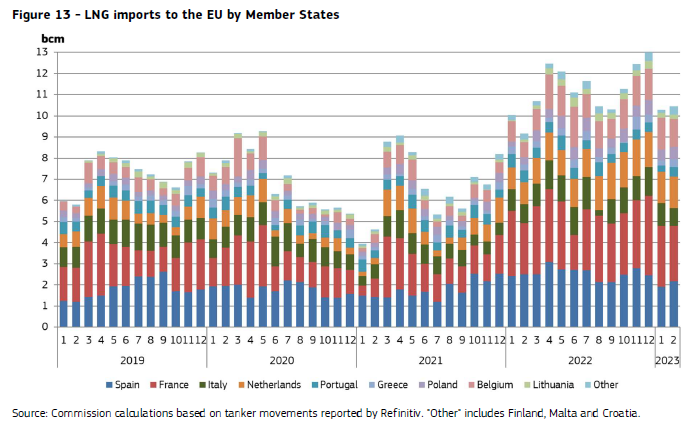

In [41]:
from IPython.display import Image, display
display(Image("Commission Qreport 2023.png",width=1200)) # to change after new Commission's gas report

#### checks for Spain

In [42]:
df[df['name']=='TVB (Virtual balancing LNG tank)']['sendOut']

KeyError: 'name'

In [43]:
tvb = df[df['name']=='TVB (Virtual balancing LNG tank)']['2021':]
tvb_plot = tvb.groupby(pd.Grouper(freq='W'))['sendOut'].sum()
esp = df[df['country']=='ES']['2021':]
esp_plot = esp.groupby(pd.Grouper(freq='W'))['sendOut'].sum(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(tvb_plot,label='TVB',linestyle=':')
ax.plot(esp_plot,label='ES aggregate')

plt.xticks(rotation=45)
plt.title('Check for ES LNG',fontsize='16')
plt.ylabel('GWh',fontsize=12,loc='center')
plt.legend(loc='best')

KeyError: 'name'

In [44]:
import os
os.getcwd()

'C:\\Users\\ugne.keliauskaite\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\LNG'

In [45]:
df.country.unique()

array(['BE', 'DE', 'ES', 'FI', 'FR', 'GR', 'HR', 'IT', 'LT', 'NL', 'PL',
       'PT'], dtype=object)